In [1]:
# ======================================================
# Random Forest Model - Import Libraries
# ======================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

import joblib

In [2]:
# ======================================================
# Load Dataset
# ======================================================

data_path = Path("../data/processed/application_train_feature_engineered.csv")

feature_df = pd.read_csv(data_path)

print(feature_df.shape)

feature_df.head()

(307511, 249)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,AGE_GROUP_30-40,AGE_GROUP_40-50,AGE_GROUP_50-60,AGE_GROUP_60-70,INCOME_GROUP_Low,INCOME_GROUP_Medium,INCOME_GROUP_Very High,INCOME_GROUP_Very Low
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0,0,0,1,0,0,0,0,1,0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0,0,0,0,1,0,0,0,0,1
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0,0,0,0,1,0,1,0,0,0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0,0,0,0,1,0,1,0,0,0


In [3]:
# ======================================================
# Feature & Target
# ======================================================

X = feature_df.drop(columns=["TARGET"])

y = feature_df["TARGET"]

print(X.shape)

print(y.shape)

(307511, 248)
(307511,)


In [4]:
# ======================================================
# Train Test Split
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(246008, 248)
(61503, 248)


In [5]:
# ======================================================
# Train Random Forest
# ======================================================

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf_model.fit(X_train,y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [6]:
# ======================================================
# Prediction
# ======================================================

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

In [7]:
# ======================================================
# Evaluation
# ======================================================

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

roc_auc = roc_auc_score(y_test,y_prob)

print("="*45)

print("Random Forest Performance")

print("="*45)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC  : {roc_auc:.4f}")

Random Forest Performance
Accuracy : 0.8360
Precision: 0.2224
Recall   : 0.4133
F1 Score : 0.2892
ROC AUC  : 0.7456


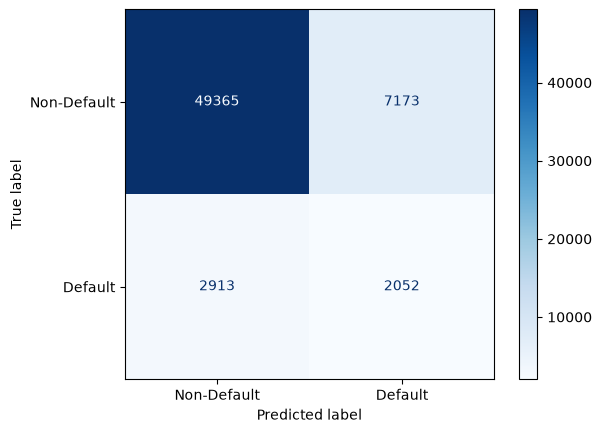

In [8]:
# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Non-Default","Default"]

)

disp.plot(cmap="Blues")

plt.show()

In [9]:
# ======================================================
# Classification Report
# ======================================================

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.87      0.91     56538
           1       0.22      0.41      0.29      4965

    accuracy                           0.84     61503
   macro avg       0.58      0.64      0.60     61503
weighted avg       0.89      0.84      0.86     61503



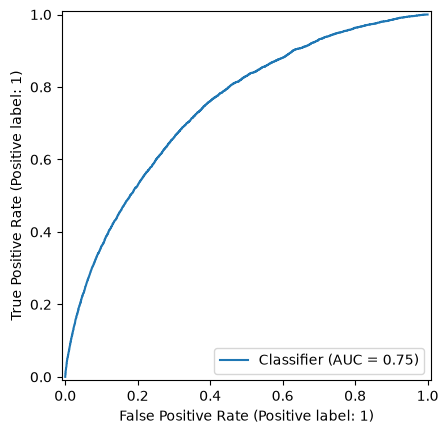

In [10]:
# ======================================================
# ROC Curve
# ======================================================

RocCurveDisplay.from_predictions(y_test,y_prob)

plt.show()

In [11]:
# ======================================================
# Feature Importance
# ======================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
113,EXT_SOURCE_MEAN,0.112530
30,EXT_SOURCE_3,0.057776
29,EXT_SOURCE_2,0.055171
112,LOAN_BURDEN,0.024889
28,EXT_SOURCE_1,0.024382
110,EMPLOYMENT_RATIO,0.023931
109,YEARS_EMPLOYED,0.021809
7,DAYS_BIRTH,0.021391
111,AGE,0.021043
10,DAYS_ID_PUBLISH,0.019459


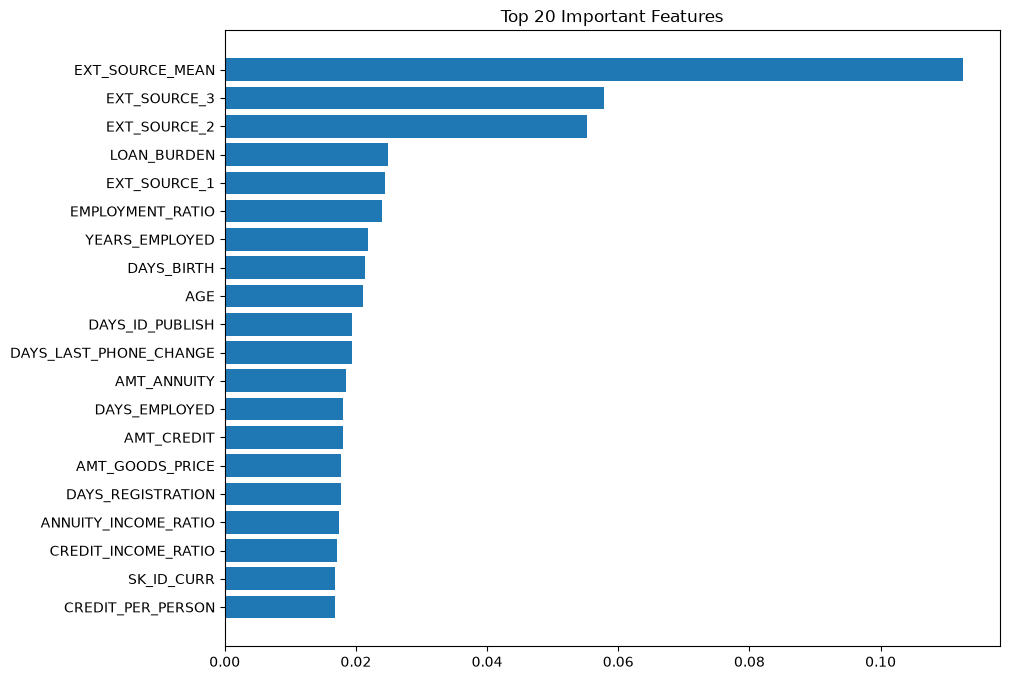

In [12]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["Importance"][:20]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [13]:
# ======================================================
# Save Model
# ======================================================

model_path = Path("../models")

model_path.mkdir(

    parents=True,

    exist_ok=True

)

joblib.dump(

    rf_model,

    model_path/"random_forest.pkl"

)

print("Random Forest Saved Successfully!")

Random Forest Saved Successfully!
